1: Import Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import savgol_filter
from scipy.optimize import lsq_linear

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla V100-SXM2-16GB


2: Data Loading and Extended Feature Construction

In [3]:
default_dataset_candidates = [
    'dataset3.npz',
]

def _resolve_dataset_path(candidates):
    for candidate in candidates:
        if os.path.isabs(candidate):
            path = candidate
        else:
            path = os.path.abspath(os.path.join(os.getcwd(), candidate))
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        "Unable to locate any dataset file. Checked: " + ", ".join(candidates)
    )

DATASET_PATH = _resolve_dataset_path(default_dataset_candidates)
print(f"Loading dataset from: {DATASET_PATH}")

data = np.load(DATASET_PATH)
wavenumber_axis = data['wavenumber_axis']
composite = data['composite']
component_spectra = {
    'alpha_helix': data['alpha_helix'],
    'beta_sheet': data['beta_sheet'],
    'beta_turn': data['beta_turn'],
    'other_peaks': data['other_peaks'],
}
component_order = ['alpha_helix', 'beta_sheet', 'beta_turn', 'other_peaks']
alpha_helix = component_spectra['alpha_helix']
beta_sheet = component_spectra['beta_sheet']
beta_turn = component_spectra['beta_turn']
other_peaks = component_spectra['other_peaks']

N, L = composite.shape
print(f"Dataset loaded: {N} samples, {L} wavenumber points")
print(f"Wavenumber range: {wavenumber_axis.min():.1f} - {wavenumber_axis.max():.1f} cm⁻¹")

# update the peak table to match the new wavenumber range
peak_table_flat = [
    ("beta_sheet", 1624), ("beta_sheet", 1627), ("beta_sheet", 1633),
    ("beta_sheet", 1638), ("beta_sheet", 1642), ("beta_sheet", 1691),
    ("beta_sheet", 1696), ("alpha_helix", 1656),
    ("beta_turn", 1667), ("beta_turn", 1675), ("beta_turn", 1680), ("beta_turn", 1685),
]

# verify if the peaks are within the wavenumber range
valid_peaks = []
for peak_type, center in peak_table_flat:
    if wavenumber_axis.min() <= center <= wavenumber_axis.max():
        valid_peaks.append((peak_type, center))
    else:
        print(f"Warning: Peak {peak_type} at {center} cm⁻¹ is outside wavenumber range")

if len(valid_peaks) < len(peak_table_flat):
    print(f"Using {len(valid_peaks)} valid peaks out of {len(peak_table_flat)} original peaks")
    peak_table_flat = valid_peaks

delta = 2.0
def extract_integral_features(spectrum, wavenumber_axis, peak_table_flat, delta=2.0):
    """
    Extract extended statistical features within peak regions
    Including: integral, maximum, mean, median, standard deviation, variance, minimum, skewness, kurtosis
    """
    features = []
    for _, center in peak_table_flat:
        mask = (wavenumber_axis >= center - delta) & (wavenumber_axis <= center + delta)
        if np.any(mask):
            peak_region = spectrum[mask]
            if len(peak_region) > 0:
                # Basic statistical features
                integral = peak_region.sum()  # Integral
                max_val = peak_region.max()   # Maximum
                min_val = peak_region.min()   # Minimum
                mean_val = peak_region.mean() # Mean
                median_val = np.median(peak_region)  # Median
                
                # Variance and standard deviation
                var_val = peak_region.var()
                std_val = peak_region.std()
                
                # Skewness and kurtosis (requires at least 3 points)
                if len(peak_region) >= 3:
                    skewness = ((peak_region - mean_val) ** 3).mean() / (std_val ** 3) if std_val > 0 else 0
                    kurtosis = ((peak_region - mean_val) ** 4).mean() / (std_val ** 4) if std_val > 0 else 0
                else:
                    skewness = 0
                    kurtosis = 0
                
                # Combine all features
                peak_features = [
                    integral, max_val, min_val, mean_val, median_val,
                    var_val, std_val, skewness, kurtosis
                ]
            else:
                peak_features = [0.0] * 9  # Set all 9 features to 0
        else:
            peak_features = [0.0] * 9  # Set all 9 features to 0
        
        features.extend(peak_features)
    
    return np.array(features)
X_integral = np.stack([
    extract_integral_features(s, wavenumber_axis, peak_table_flat, delta=delta)
    for s in composite
])

# Feature dimension explanation:
# Each peak region extracts 9 features: integral, maximum, minimum, mean, median, variance, standard deviation, skewness, kurtosis
# Total of 12 peak regions, so feature dimension is 12 * 9 = 108
print(f"Statistical feature dimension: {X_integral.shape[1]} (9 features per peak region × {len(peak_table_flat)} peak regions)")


Loading dataset from: /projectnb/cislbu/Anqi_Wei/UOL/dataset3.npz
Dataset loaded: 10000 samples, 441 wavenumber points
Wavenumber range: 1360.0 - 1800.0 cm⁻¹
Statistical feature dimension: 108 (9 features per peak region × 12 peak regions)


3: Peak Table Definition

In [4]:
peak_table = {
    "beta_sheet": [
        (1624, 1.0, 12.0), (1627, 2.0, 12.0), (1633, 2.0, 12.0),
        (1638, 2.0, 12.0), (1642, 1.0, 12.0), (1691, 2.0, 12.0), (1696, 2.0, 12.0)
    ],
    "alpha_helix": [(1656, 2.0, 12.0)],
    "beta_turn": [
        (1667, 1.0, 12.0), (1675, 1.0, 12.0), (1680, 2.0, 12.0), (1685, 2.0, 12.0)
    ],
}

# Add new peak detection function using decomposed spectral data
def extract_decomposed_features(spectrum, wavenumber_axis, peak_table, delta=2.0):
    features = []
    
    # Extract features for each peak region
    for _, center in peak_table_flat:
        mask = (wavenumber_axis >= center - delta) & (wavenumber_axis <= center + delta)
        if np.any(mask):
            peak_region = spectrum[mask]
            if len(peak_region) > 0:
                # Basic statistical features
                integral = peak_region.sum()
                max_val = peak_region.max()
                min_val = peak_region.min()
                mean_val = peak_region.mean()
                median_val = np.median(peak_region)
                
                # Variance and standard deviation
                var_val = peak_region.var()
                std_val = peak_region.std()
                
                # Skewness and kurtosis
                if len(peak_region) >= 3:
                    skewness = ((peak_region - mean_val) ** 3).mean() / (std_val ** 3) if std_val > 0 else 0
                    kurtosis = ((peak_region - mean_val) ** 4).mean() / (std_val ** 4) if std_val > 0 else 0
                else:
                    skewness = 0
                    kurtosis = 0
                
                peak_features = [
                    integral, max_val, min_val, mean_val, median_val,
                    var_val, std_val, skewness, kurtosis
                ]
            else:
                peak_features = [0.0] * 9
        else:
            peak_features = [0.0] * 9
        
        features.extend(peak_features)
    
    return np.array(features)

3.5: Peak Detection and Classification Functions

In [ ]:
def detect_peaks(y, x_axis, threshold=0.2, window=20, min_distance=50):
    y_smooth = savgol_filter(y, window_length=21, polyorder=3)
    dy = np.gradient(y_smooth)
    d2y = np.gradient(dy)
    candidates = []
    for i in range(1, len(y_smooth)-1):
        if dy[i-1] > 0 and dy[i+1] < 0 and d2y[i] < 0 and y_smooth[i] > threshold:
            candidates.append(i)
    filtered = []
    for idx in candidates:
        left = max(0, idx-window)
        right = min(len(y_smooth), idx+window)
        if y_smooth[idx] == np.max(y_smooth[left:right]):
            filtered.append(idx)
    final = []
    last_idx = -min_distance
    for idx in filtered:
        if idx - last_idx >= min_distance:
            final.append(idx)
            last_idx = idx
    return np.array(final), y_smooth

def classify_peak(peak_wavenumber, peak_table, delta_multiplier=1.2):
    for family, peaks in peak_table.items():
        for center, delta, gamma in peaks:
            wide_delta = max(delta, 1.5) * delta_multiplier
            if abs(peak_wavenumber - center) <= wide_delta:
                return family, gamma
    return None, None

def lorentzian(x, x0, gamma):
    return 1 / (1 + ((x - x0) / (gamma / 2))**2)

def lorentzian_area(amplitude, gamma):
    """Calculate the area of Lorentzian function: area = π * γ * A / 2"""
    return np.pi * gamma * amplitude / 2

def extract_nnls_fitting_features(spectrum, wavenumber_axis, peak_table, gamma_width=31):
    """
    Extract extended features based on NNLS fitting
    Including: peak position, amplitude, area, peak width, fitting residuals, R², etc.
    
    Parameters:
    -----------
    spectrum : array
        Spectral data
    wavenumber_axis : array
        Wavenumber axis
    peak_table : dict
        Peak table
    gamma_width : float
        Default peak width
    
    Returns:
    --------
    features : array
        Fitting feature vector
    """
    # Peak detection
    peak_indices, y_smooth = detect_peaks(spectrum, wavenumber_axis, 
                                         threshold=0.2, window=20, min_distance=50)
    if len(peak_indices) > 0:
        peak_indices = peak_indices.astype(int)
        peak_indices = np.asarray(peak_indices, dtype=int)
        if len(peak_indices) > 0:
            peak_indices = np.asarray(peak_indices, dtype=int)
            detected_positions = wavenumber_axis[peak_indices]
        else:
            detected_positions = np.array([])
    else:
        detected_positions = np.array([])
    
    # Peak classification
    selected_centers, selected_types, selected_gammas = [], [], []
    for p in detected_positions:
        fam, gamma = classify_peak(p, peak_table)
        if fam is not None:
            selected_centers.append(p)
            selected_types.append(fam)
            selected_gammas.append(gamma)
    
    selected_centers = np.array(selected_centers)
    selected_types = np.array(selected_types)
    selected_gammas = np.array(selected_gammas)
    
    # Initialize fixed-length feature vector
    total_features = 12 * 7 + 7  # 12 peaks × 7 features + 7 global features
    features = np.zeros(total_features)
    
    # If no peaks detected, return zero features
    if len(selected_centers) == 0:
        return features
    
    # NNLS fitting
    B = np.stack([lorentzian(wavenumber_axis, c, g) for c, g in zip(selected_centers, selected_gammas)], axis=1)
    B /= B.max(axis=0, keepdims=True)
    res = lsq_linear(B, spectrum, bounds=(0, np.inf), lsq_solver='exact')
    amplitudes = res.x
    
    # Calculate fitting residuals and R²
    recon = B @ amplitudes
    residuals = spectrum - recon
    mse = np.mean(residuals**2)
    ss_tot = np.sum((spectrum - np.mean(spectrum))**2)
    ss_res = np.sum(residuals**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Calculate area for each peak
    areas = lorentzian_area(amplitudes, selected_gammas)
    
    # Fill peak features (maximum 12 peaks)
    for i, (center, amp, area, gamma, peak_type) in enumerate(zip(selected_centers, amplitudes, areas, selected_gammas, selected_types)):
        if i >= 12:  # Process maximum 12 peaks
            break
            
        # Basic peak parameters
        peak_features = [
            amp,      # Amplitude
            area,     # Area
            center,   # Peak position
            gamma,    # Peak width
        ]
        
        # Peak type encoding (one-hot encoding)
        type_encoding = [0, 0, 0]  # [alpha_helix, beta_sheet, beta_turn]
        if peak_type == 'alpha_helix':
            type_encoding[0] = 1
        elif peak_type == 'beta_sheet':
            type_encoding[1] = 1
        elif peak_type == 'beta_turn':
            type_encoding[2] = 1
        
        peak_features.extend(type_encoding)
        
        # Fill into feature vector
        start_idx = i * 7
        features[start_idx:start_idx + 7] = peak_features
    
    # Add global fitting quality features (last 7 positions)
    global_features = [
        mse,           # Mean squared error
        r_squared,     # R²
        len(selected_centers),  # Number of detected peaks
        np.mean(amplitudes),    # Mean amplitude
        np.std(amplitudes),     # Amplitude standard deviation
        np.mean(areas),         # Mean area
        np.std(areas),          # Area standard deviation
    ]
    
    features[-7:] = global_features
    
    return features

2.5: NNLS Fitting Feature Extraction

In [6]:
# Extract richer features using decomposed spectral data
print("Extracting features from decomposed spectra...")

# 1. Extract statistical features from composite spectra
X_integral = np.stack([
    extract_integral_features(s, wavenumber_axis, peak_table_flat, delta=delta)
    for s in composite
])

# 2. Extract features from decomposed spectra
def extract_decomposed_spectra_features(components, component_order, wavenumber_axis, peak_table_flat, delta=2.0):
    features = []
    num_samples = len(next(iter(components.values())))
    
    for i in range(num_samples):
        sample_features = []
        for name in component_order:
            component_matrix = components[name]
            comp_features = extract_integral_features(component_matrix[i], wavenumber_axis, peak_table_flat, delta)
            sample_features.extend(comp_features)
        features.append(sample_features)
    
    return np.array(features)

# 3. New: Peak detection and identification features
def extract_peak_detection_features(composite, wavenumber_axis, peak_table, max_peaks=15):
    """
    Extract peak detection and identification features
    Including: peak position, amplitude, peak width, peak type, other information, etc.
    """
    features = []
    
    for spectrum in composite:
        sample_features = []
        
        # Peak detection
        peak_indices, y_smooth = detect_peaks(spectrum, wavenumber_axis, 
                                             threshold=0.1, window=15, min_distance=30)
        
        if len(peak_indices) > 0:
            peak_indices = peak_indices.astype(int)
            detected_positions = wavenumber_axis[peak_indices]
            detected_amplitudes = spectrum[peak_indices]
            
            # Limit maximum number of peaks
            n_peaks = min(len(detected_positions), max_peaks)
            
            for i in range(max_peaks):
                if i < n_peaks:
                    # Peak position (normalized to 0-1)
                    pos = (detected_positions[i] - wavenumber_axis.min()) / (wavenumber_axis.max() - wavenumber_axis.min())
                    # Peak amplitude (normalized)
                    amp = detected_amplitudes[i] / spectrum.max()
                    # Peak type encoding
                    peak_type, _ = classify_peak(detected_positions[i], peak_table)
                    type_encoding = [0, 0, 0, 0]  # [alpha_helix, beta_sheet, beta_turn, other]
                    if peak_type == 'alpha_helix':
                        type_encoding[0] = 1
                    elif peak_type == 'beta_sheet':
                        type_encoding[1] = 1
                    elif peak_type == 'beta_turn':
                        type_encoding[2] = 1
                    else:
                        type_encoding[3] = 1  # other
                    
                    # Combine features: position, amplitude, type encoding
                    peak_features = [pos, amp] + type_encoding
                else:
                    # Fill with zero features
                    peak_features = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                
                sample_features.extend(peak_features)
        else:
            # No peaks detected, fill all with zeros
            sample_features.extend([0.0] * (max_peaks * 6))
        
        features.append(sample_features)
    
    return np.array(features)

# Extract decomposed spectral features
X_decomposed = extract_decomposed_spectra_features(
    component_spectra, component_order, wavenumber_axis, peak_table_flat, delta
)

print(f"Decomposed spectra feature dimension: {X_decomposed.shape[1]} ({len(component_order)} spectra × {len(peak_table_flat)} peaks × 9 features)")

# Extract peak detection features
X_peak_detection = extract_peak_detection_features(composite, wavenumber_axis, peak_table, max_peaks=15)
print(f"Peak detection feature dimension: {X_peak_detection.shape[1]} (15 peaks × 6 features)")

# 4. Extract NNLS fitting features from composite spectra
X_nnls = np.stack([
    extract_nnls_fitting_features(s, wavenumber_axis, peak_table, gamma_width=31)
    for s in composite
])

print(f"NNLS fitting feature dimension: {X_nnls.shape[1]}")

# 5. Combine all features
X_combined = np.concatenate([X_integral, X_decomposed, X_peak_detection, X_nnls], axis=1)
print(f"Combined feature dimension: {X_combined.shape[1]} (integral: {X_integral.shape[1]} + decomposed: {X_decomposed.shape[1]} + peak_detection: {X_peak_detection.shape[1]} + NNLS: {X_nnls.shape[1]})")


Extracting features from decomposed spectra...
Decomposed spectra feature dimension: 432 (4 spectra × 12 peaks × 9 features)
Peak detection feature dimension: 90 (15 peaks × 6 features)
NNLS fitting feature dimension: 91
Combined feature dimension: 721 (integral: 108 + decomposed: 432 + peak_detection: 90 + NNLS: 91)


2.6: PCA Feature Dimensionality Reduction

Applying PCA dimensionality reduction...
Reducing features from 721 to 300 dimensions
PCA reduction completed!
Explained variance ratio: 1.0000
Top 10 components explain: [0.08836696 0.15096811 0.20415589 0.25452504 0.30033652 0.3417721
 0.37884947 0.41362937 0.4472905  0.48078508]


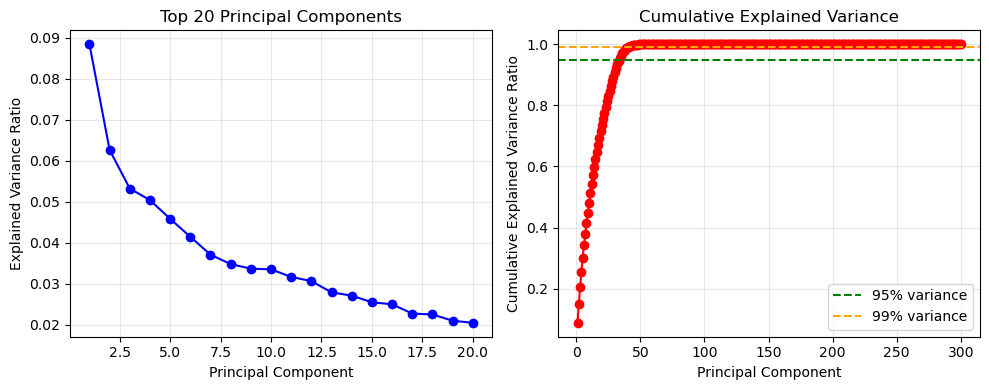

Final feature dimension after PCA: 300


In [7]:
print("Applying PCA dimensionality reduction...")

from sklearn.decomposition import PCA

# Set target dimension (reduce from 937 dimensions to 300 dimensions)
target_dim = 300
print(f"Reducing features from {X_combined.shape[1]} to {target_dim} dimensions")

# Apply PCA dimensionality reduction
pca = PCA(n_components=target_dim, random_state=42)
X_combined_pca = pca.fit_transform(X_combined)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print(f"PCA reduction completed!")
print(f"Explained variance ratio: {explained_variance_ratio.sum():.4f}")
print(f"Top 10 components explain: {cumulative_variance_ratio[:10]}")

# 可视化PCA解释方差
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, min(21, target_dim+1)), explained_variance_ratio[:20], 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Top 20 Principal Components')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, target_dim+1), cumulative_variance_ratio, 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% variance')
plt.legend()

plt.tight_layout()
plt.show()

# 使用降维后的特征
X_combined = X_combined_pca
print(f"Final feature dimension after PCA: {X_combined.shape[1]}")

4: NNLS β/α Label Generation (Based on Area Ratio)

In [8]:
print("Generating β/α ratio labels using decomposed spectra...")

# Method 1: Direct calculation of area ratio from decomposed spectra (more accurate)
def calculate_area_ratio_from_decomposed(components, wavenumber_axis):
    """Calculate β/α area ratio directly from decomposed spectra."""
    ratios = []
    valid_indices = []
    alpha = components['alpha_helix']
    beta_sheet = components['beta_sheet']
    beta_turn = components['beta_turn']
    area_fn = getattr(np, 'trapezoid', np.trapz)
    
    for idx in range(len(alpha)):
        alpha_area = area_fn(alpha[idx], wavenumber_axis)
        beta_sheet_area = area_fn(beta_sheet[idx], wavenumber_axis)
        beta_turn_area = area_fn(beta_turn[idx], wavenumber_axis)
        beta_total_area = beta_sheet_area + beta_turn_area
        
        if alpha_area > 1e-8:
            ratios.append(beta_total_area / alpha_area)
            valid_indices.append(idx)
        else:
            print(f"Warning: Sample {idx} has near-zero alpha helix area")
    
    return np.array(ratios), np.array(valid_indices)

# Method 2: Traditional method using NNLS fitting (for comparison)
def calculate_area_ratio_from_nnls(composite, wavenumber_axis, peak_table):
    """
    Calculate β/α area ratio using NNLS fitting (traditional method)
    """
    alpha_areas, beta_areas, ratios, valid_indices = [], [], [], []
    
    for idx, y in enumerate(composite):
        peak_indices, y_smooth = detect_peaks(y, wavenumber_axis)
        if len(peak_indices) == 0:
            continue
        peak_indices = np.asarray(peak_indices, dtype=int)
        detected_positions = wavenumber_axis[peak_indices]
        if detected_positions.size == 0:
            continue
        selected_centers, selected_types, selected_gammas = [], [], []
        
        for p in detected_positions:
            fam, gamma = classify_peak(p, peak_table)
            if fam is not None:
                selected_centers.append(p)
                selected_types.append(fam)
                selected_gammas.append(gamma)
        
        selected_centers = np.array(selected_centers)
        selected_types = np.array(selected_types)
        selected_gammas = np.array(selected_gammas)
        
        if len(selected_centers) == 0 or not np.any(selected_types == 'alpha_helix'):
            continue
            
        B = np.stack([lorentzian(wavenumber_axis, c, g) for c, g in zip(selected_centers, selected_gammas)], axis=1)
        B /= B.max(axis=0, keepdims=True)
        res = lsq_linear(B, y, bounds=(0, np.inf), lsq_solver='exact')
        amplitudes = res.x
        
        # Calculate area for each peak
        areas = lorentzian_area(amplitudes, selected_gammas)
        
        # Calculate total area of α and β regions
        alpha_area = areas[selected_types == 'alpha_helix'].sum()
        beta_area = areas[(selected_types == 'beta_sheet') | (selected_types == 'beta_turn')].sum()
        
        if alpha_area <= 1e-8:
            continue
            
        alpha_areas.append(alpha_area)
        beta_areas.append(beta_area)
        ratios.append(beta_area / alpha_area)
        valid_indices.append(idx)
    
    return np.array(ratios), np.array(valid_indices)

# Use decomposed spectra method to generate labels (recommended)
y_decomposed, valid_indices_decomposed = calculate_area_ratio_from_decomposed(
    component_spectra, wavenumber_axis
)

# Use NNLS method to generate labels (for comparison)
y_nnls, valid_indices_nnls = calculate_area_ratio_from_nnls(composite, wavenumber_axis, peak_table)

print(f"Decomposed method: {len(y_decomposed)} valid samples, ratio range: {y_decomposed.min():.3f} - {y_decomposed.max():.3f}")
if y_nnls.size > 0:
    print(f"NNLS method: {len(y_nnls)} valid samples, ratio range: {y_nnls.min():.3f} - {y_nnls.max():.3f}")
else:
    print("NNLS method: 0 valid samples (skipping range computation)")

# Choose which method to use (recommended to use decomposed spectra method)
use_decomposed_method = True

if use_decomposed_method:
    y = y_decomposed
    valid_indices = valid_indices_decomposed
    print("Using decomposed spectra method for label generation")
else:
    y = y_nnls
    valid_indices = valid_indices_nnls
    print("Using NNLS method for label generation")

# Apply log transformation to ratios (for regression)
y = np.log1p(y)
print(f"Log-transformed labels: range {y.min():.3f} - {y.max():.3f}")

Generating β/α ratio labels using decomposed spectra...
Decomposed method: 10000 valid samples, ratio range: 0.818 - 6.081
NNLS method: 0 valid samples (skipping range computation)
Using decomposed spectra method for label generation
Log-transformed labels: range 0.598 - 1.957


4.5: Label Distribution Analysis

Analyzing label distribution...


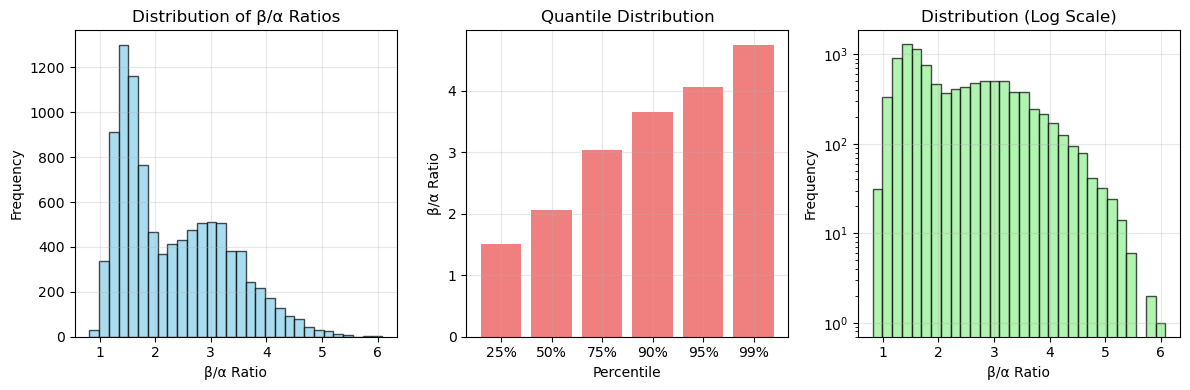

β/α Ratio Statistics:
  Mean: 2.320
  Std: 0.948
  Min: 0.818
  Max: 6.081
  25th percentile: 1.510
  50th percentile: 2.061
  75th percentile: 3.038
  90th percentile: 3.655
  95th percentile: 4.061
  99th percentile: 4.746

Data Balance Analysis:
  High β/α ratio samples (> 3.655): 1000 (10.0%)
  Low β/α ratio samples (≤ 3.655): 9000 (90.0%)


In [9]:
print("Analyzing label distribution...")

def analyze_label_distribution(y):
    """
    Analyze label distribution to identify data imbalance issues
    """
    # Convert back to original ratios (remove log1p)
    original_ratios = np.expm1(y)
    
    plt.figure(figsize=(12, 4))
    
    # Histogram
    plt.subplot(1, 3, 1)
    plt.hist(original_ratios, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('β/α Ratio')
    plt.ylabel('Frequency')
    plt.title('Distribution of β/α Ratios')
    plt.grid(True, alpha=0.3)
    
    # Quantile plot
    plt.subplot(1, 3, 2)
    quantiles = np.percentile(original_ratios, [25, 50, 75, 90, 95, 99])
    plt.bar(range(len(quantiles)), quantiles, color='lightcoral')
    plt.xlabel('Percentile')
    plt.ylabel('β/α Ratio')
    plt.title('Quantile Distribution')
    plt.xticks(range(len(quantiles)), ['25%', '50%', '75%', '90%', '95%', '99%'])
    plt.grid(True, alpha=0.3)
    
    # Log scale histogram
    plt.subplot(1, 3, 3)
    plt.hist(original_ratios, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    plt.xlabel('β/α Ratio')
    plt.ylabel('Frequency')
    plt.title('Distribution (Log Scale)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"β/α Ratio Statistics:")
    print(f"  Mean: {original_ratios.mean():.3f}")
    print(f"  Std: {original_ratios.std():.3f}")
    print(f"  Min: {original_ratios.min():.3f}")
    print(f"  Max: {original_ratios.max():.3f}")
    print(f"  25th percentile: {quantiles[0]:.3f}")
    print(f"  50th percentile: {quantiles[1]:.3f}")
    print(f"  75th percentile: {quantiles[2]:.3f}")
    print(f"  90th percentile: {quantiles[3]:.3f}")
    print(f"  95th percentile: {quantiles[4]:.3f}")
    print(f"  99th percentile: {quantiles[5]:.3f}")
    
    # Check data imbalance
    high_ratio_threshold = np.percentile(original_ratios, 90)  # 90th percentile as high value threshold
    high_ratio_count = np.sum(original_ratios > high_ratio_threshold)
    high_ratio_percentage = high_ratio_count / len(original_ratios) * 100
    
    print(f"\nData Balance Analysis:")
    print(f"  High β/α ratio samples (> {high_ratio_threshold:.3f}): {high_ratio_count} ({high_ratio_percentage:.1f}%)")
    print(f"  Low β/α ratio samples (≤ {high_ratio_threshold:.3f}): {len(original_ratios) - high_ratio_count} ({100-high_ratio_percentage:.1f}%)")
    
    if high_ratio_percentage < 10:
        print(f"  ⚠️  Warning: High β/α ratio samples are underrepresented!")
        print(f"  💡  Consider using weighted loss function or data augmentation")
    
    return original_ratios, high_ratio_threshold

# Analyze label distribution
original_ratios, high_ratio_threshold = analyze_label_distribution(y)

4.6: Feature Selection Based on Importance

Performing feature selection based on importance...
Training Random Forest to evaluate feature importance...
Feature selection completed!
Selected 100 most important features out of 300
Final feature dimension after selection: 100


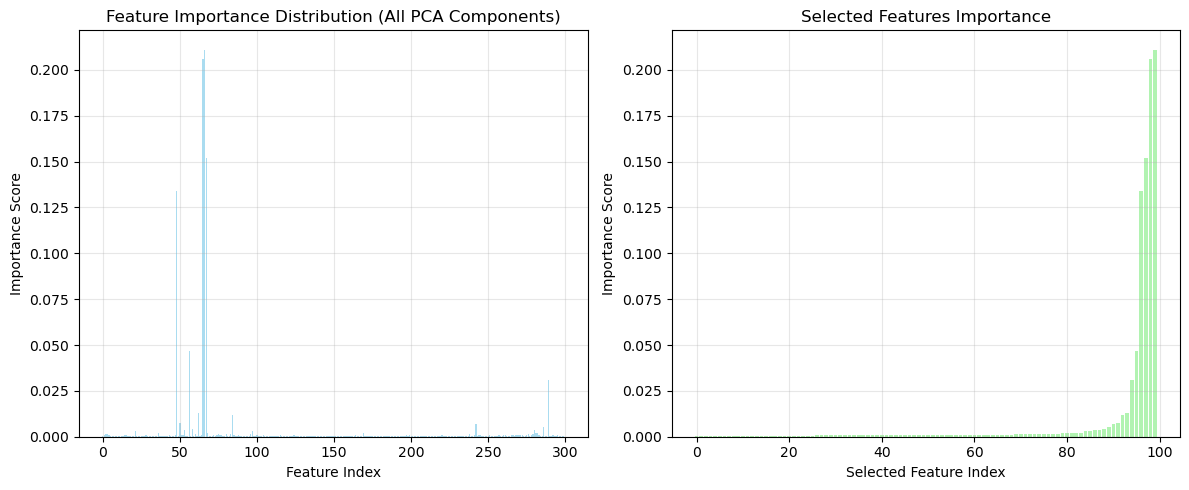

Top 10 most important features:
  Feature  93: 0.000558
  Feature  22: 0.000561
  Feature  70: 0.000562
  Feature 258: 0.000563
  Feature  78: 0.000569
  Feature  27: 0.000574
  Feature 230: 0.000576
  Feature 277: 0.000585
  Feature 191: 0.000589
  Feature  69: 0.000596


In [10]:
print("Performing feature selection based on importance...")

def select_important_pca_features(X_pca, y, n_components=100):
    """
    After PCA dimensionality reduction, select the most important principal components based on importance
    """
    from sklearn.ensemble import RandomForestRegressor
    
    print(f"Training Random Forest to evaluate feature importance...")
    
    # Train Random Forest to evaluate feature importance
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_pca, y)
    
    # Get feature importance
    importance = rf.feature_importances_
    
    # Select the most important n_components features
    top_indices = importance.argsort()[-n_components:]
    X_selected = X_pca[:, top_indices]
    
    print(f"Feature selection completed!")
    print(f"Selected {n_components} most important features out of {X_pca.shape[1]}")
    
    return X_selected, top_indices, importance

# Select the most important 100 features
X_combined_selected, selected_indices, feature_importance = select_important_pca_features(
    X_combined, y, n_components=100
)

# Update feature matrix
X_combined = X_combined_selected
print(f"Final feature dimension after selection: {X_combined.shape[1]}")

# Visualize feature importance distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(feature_importance)), feature_importance, alpha=0.7, color='skyblue')
plt.xlabel('Feature Index')
plt.ylabel('Importance Score')
plt.title('Feature Importance Distribution (All PCA Components)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
selected_importance = feature_importance[selected_indices]
plt.bar(range(len(selected_importance)), selected_importance, alpha=0.7, color='lightgreen')
plt.xlabel('Selected Feature Index')
plt.ylabel('Importance Score')
plt.title('Selected Features Importance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Top 10 most important features:")
for i in range(min(10, len(selected_indices))):
    idx = selected_indices[i]
    importance = feature_importance[idx]
    print(f"  Feature {idx:3d}: {importance:.6f}")

5: Normalization and Splitting

In [11]:
print("Validating and preprocessing data...")

# 验证数据完整性
if len(valid_indices) == 0:
    raise ValueError("No valid samples found! Check your data and peak definitions.")

print(f"Valid samples: {len(valid_indices)} out of {N} total samples")

# 提取有效样本的特征和光谱
X_combined_valid = X_combined[valid_indices]
composite_valid = composite[valid_indices]

# 验证特征维度
print(f"Feature matrix shape: {X_combined_valid.shape}")
print(f"Spectra matrix shape: {composite_valid.shape}")
print(f"Labels shape: {y.shape}")

# 检查是否有NaN或无穷大值
if np.any(np.isnan(X_combined_valid)) or np.any(np.isinf(X_combined_valid)):
    print("Warning: Found NaN or infinite values in features, cleaning...")
    X_combined_valid = np.nan_to_num(X_combined_valid, nan=0.0, posinf=0.0, neginf=0.0)

if np.any(np.isnan(composite_valid)) or np.any(np.isinf(composite_valid)):
    print("Warning: Found NaN or infinite values in spectra, cleaning...")
    composite_valid = np.nan_to_num(composite_valid, nan=0.0, posinf=0.0, neginf=0.0)

if np.any(np.isnan(y)) or np.any(np.isinf(y)):
    print("Warning: Found NaN or infinite values in labels, cleaning...")
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

# 光谱标准化
mean_spec = composite_valid.mean()
std_spec = composite_valid.std()
if std_spec < 1e-8:
    print("Warning: Very small standard deviation in spectra, using identity normalization")
    X_spectra_norm = composite_valid - mean_spec
else:
    X_spectra_norm = (composite_valid - mean_spec) / std_spec

print(f"Spectra normalization: mean={mean_spec:.6f}, std={std_spec:.6f}")

# 特征标准化（可选）
feature_mean = X_combined_valid.mean(axis=0)
feature_std = X_combined_valid.std(axis=0)
feature_std[feature_std < 1e-8] = 1.0  # 避免除零
X_features_norm = (X_combined_valid - feature_mean) / feature_std

print(f"Feature normalization: mean range [{feature_mean.min():.6f}, {feature_mean.max():.6f}]")
print(f"Feature normalization: std range [{feature_std.min():.6f}, {feature_std.max():.6f}]")

# 数据分割
X_train_spec, X_test_spec, X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    X_spectra_norm, X_features_norm, y, test_size=0.15, random_state=42, stratify=None
)
X_train_spec, X_val_spec, X_train_feat, X_val_feat, y_train, y_val = train_test_split(
    X_train_spec, X_train_feat, y_train, test_size=0.15/0.85, random_state=42, stratify=None
)

print(f"Training set: {len(X_train_spec)} samples")
print(f"Validation set: {len(X_val_spec)} samples") 
print(f"Test set: {len(X_test_spec)} samples")


Validating and preprocessing data...
Valid samples: 10000 out of 10000 total samples
Feature matrix shape: (10000, 100)
Spectra matrix shape: (10000, 441)
Labels shape: (10000,)
Spectra normalization: mean=0.000043, std=0.000034
Feature normalization: mean range [-0.000000, 0.000000]
Feature normalization: std range [0.000000, 1.000000]
Training set: 7000 samples
Validation set: 1500 samples
Test set: 1500 samples


6: Dataset & Dataloader

In [12]:
class EarlyFusionDataset(Dataset):
    def __init__(self, X_spec, X_feat, y):
        self.spec = torch.from_numpy(X_spec).float().unsqueeze(1)
        self.feat = torch.from_numpy(X_feat).float()
        self.label = torch.from_numpy(y).float().unsqueeze(1)
    def __len__(self): return len(self.spec)
    def __getitem__(self, idx): return self.spec[idx], self.feat[idx], self.label[idx]
train_ds = EarlyFusionDataset(X_train_spec, X_train_feat, y_train)
val_ds   = EarlyFusionDataset(X_val_spec, X_val_feat, y_val)
test_ds  = EarlyFusionDataset(X_test_spec, X_test_feat, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

7: Wider and Deeper CNN + Multi-head LayerNorm Attention Early Fusion Model

In [13]:
class MultiHeadSelfAttention1D(nn.Module):
    def __init__(self, d_model, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.qkv_proj = nn.Linear(d_model, d_model * 3)
        self.fc_out = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):  # x: (B, L, d_model)
        B, L, D = x.shape
        qkv = self.qkv_proj(x).reshape(B, L, 3, self.n_heads, D // self.n_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2,-1)) / np.sqrt(D//self.n_heads)
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1,2).reshape(B, L, D)
        out = self.fc_out(out)
        return self.norm(out + x)  # Residual + normalization

class EarlyFusionNet(nn.Module):
    def __init__(self, input_spec_len, input_feat_len):
        super().__init__()
        # Wider and deeper CNN branch
        self.cnn_branch = nn.Sequential(
            nn.Conv1d(1, 128, 11, padding=5),
            nn.ReLU(),
            nn.Conv1d(128, 256, 7, padding=3),
            nn.ReLU(),
            nn.Conv1d(256, 512, 5, padding=2),
            nn.ReLU(),
            nn.Conv1d(512, 512, 3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(32)
        self.attn = MultiHeadSelfAttention1D(512, n_heads=4)
        self.flatten = nn.Flatten()
        self.cnn_fc = nn.Sequential(
            nn.Linear(512*32, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        # Deeper MLP branch + Dropout
        self.mlp_branch = nn.Sequential(
            nn.Linear(input_feat_len, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.fusion = nn.Sequential(
            nn.Linear(64+16, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, spec, feat):
        x = self.cnn_branch(spec)              # (B, 512, L)
        x = self.pool(x)                       # (B, 512, 32)
        x = x.permute(0,2,1)                   # (B, 32, 512)
        x = self.attn(x)                       # (B, 32, 512)
        x = x.permute(0,2,1).contiguous().view(x.size(0), -1)  # (B, 512*32)
        x = self.cnn_fc(x)                     # (B, 64)
        y = self.mlp_branch(feat)              # (B, 16)
        out = torch.cat([x, y], dim=1)
        return self.fusion(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EarlyFusionNet(input_spec_len=X_spectra_norm.shape[1], input_feat_len=X_combined_valid.shape[1]).to(device)


8: Training Main Loop

In [14]:
import copy

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
num_epochs = 400
patience = 40
min_delta = 1e-5

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_epoch = 0
best_state = None
wait = 0  # patience counter

for epoch in range(1, num_epochs+1):
    model.train()
    train_loss = 0.0
    for spec, feat, yb in train_loader:
        spec, feat, yb = spec.to(device), feat.to(device), yb.to(device)
        pred = model(spec, feat)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(yb)
    train_loss /= len(train_ds)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for spec, feat, yb in val_loader:
            spec, feat, yb = spec.to(device), feat.to(device), yb.to(device)
            pred = model(spec, feat)
            loss = loss_fn(pred, yb)
            val_loss += loss.item() * len(yb)
    val_loss /= len(val_ds)
    val_losses.append(val_loss)

    # Early stopping logic
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch = {best_epoch}.")
            model.load_state_dict(best_state)
            break

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs} | Train loss: {train_loss:.5f} | Val loss: {val_loss:.5f}")

print(f"Best val loss: {best_val_loss:.6f} at epoch {best_epoch}")

Epoch   1/400 | Train loss: 0.09182 | Val loss: 0.03233
Epoch  10/400 | Train loss: 0.00372 | Val loss: 0.04842
Epoch  20/400 | Train loss: 0.00271 | Val loss: 0.03472
Epoch  30/400 | Train loss: 0.00222 | Val loss: 0.02866
Epoch  40/400 | Train loss: 0.00204 | Val loss: 0.01616
Epoch  50/400 | Train loss: 0.00180 | Val loss: 0.01705
Epoch  60/400 | Train loss: 0.00173 | Val loss: 0.01107
Epoch  70/400 | Train loss: 0.00154 | Val loss: 0.00986
Epoch  80/400 | Train loss: 0.00152 | Val loss: 0.01274
Epoch  90/400 | Train loss: 0.00145 | Val loss: 0.00968
Epoch 100/400 | Train loss: 0.00242 | Val loss: 0.00637
Epoch 110/400 | Train loss: 0.00227 | Val loss: 0.00506
Epoch 120/400 | Train loss: 0.00219 | Val loss: 0.00508
Epoch 130/400 | Train loss: 0.00270 | Val loss: 0.00794
Epoch 140/400 | Train loss: 0.00206 | Val loss: 0.00411
Epoch 150/400 | Train loss: 0.00198 | Val loss: 0.00454
Epoch 160/400 | Train loss: 0.00193 | Val loss: 0.00410
Epoch 170/400 | Train loss: 0.00196 | Val loss: 

9: Test Evaluation, Binned MAE/Quantile Error/Coarse Classification Accuracy

Validation (Wider/Deeper + Multihead Attn): MAE=0.166, R2=0.942


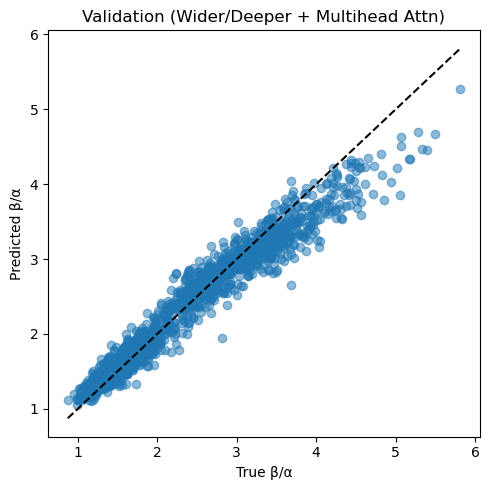

Test (Wider/Deeper + Multihead Attn): MAE=0.154, R2=0.948


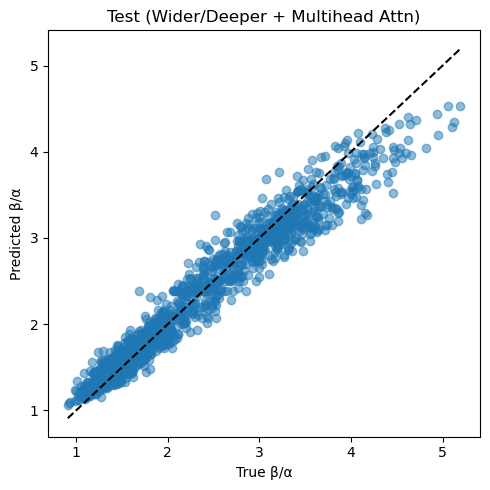

Range [0, 2): MAE = 0.107, count=731
Range [2, 3): MAE = 0.155, count=380
Range [3, 4): MAE = 0.229, count=303
Range [4, 5): MAE = 0.452, count=75
Range [5, 7): MAE = 0.765, count=11
Coarse classification accuracy: 88.1%
Confusion matrix:
 [[705  26   0   0   0]
 [ 16 343  21   0   0]
 [  0  54 247   2   0]
 [  0   0  49  26   0]
 [  0   0   1   9   1]]
Val | 50th percentile absolute error: 0.124
Val | 75th percentile absolute error: 0.218
Val | 90th percentile absolute error: 0.366
Val | 95th percentile absolute error: 0.488
Val | 99th percentile absolute error: 0.802


In [15]:
def get_preds(loader):
    model.eval()
    ys, y_preds = [], []
    with torch.no_grad():
        for spec, feat, y in loader:
            spec, feat = spec.to(device), feat.to(device)
            pred = model(spec, feat).cpu().numpy()
            ys.append(y.numpy())
            y_preds.append(pred)
    ys = np.concatenate(ys).flatten()
    y_preds = np.concatenate(y_preds).flatten()
    return np.expm1(ys), np.expm1(y_preds)
y_val_true, y_val_pred = get_preds(val_loader)
y_test_true, y_test_pred = get_preds(test_loader)

def report(y_true, y_pred, title):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{title}: MAE={mae:.3f}, R2={r2:.3f}")
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
    plt.xlabel("True β/α")
    plt.ylabel("Predicted β/α")
    plt.title(title)
    plt.tight_layout()
    plt.show()
report(y_val_true, y_val_pred, "Validation (Wider/Deeper + Multihead Attn)")
report(y_test_true, y_test_pred, "Test (Wider/Deeper + Multihead Attn)")

# --------- Binned MAE / Coarse Classification Accuracy ----------
def binned_mae_acc(y_true, y_pred, bins=[2,3,4,5,7]):
    y_true_bin = np.digitize(y_true, bins)
    y_pred_bin = np.digitize(y_pred, bins)
    for i in range(len(bins)):
        idx = (y_true_bin == i)
        if np.any(idx):
            print(f"Range [{bins[i-1] if i>0 else 0}, {bins[i]}): MAE = {mean_absolute_error(y_true[idx], y_pred[idx]):.3f}, count={idx.sum()}")
    acc = (y_true_bin == y_pred_bin).mean()
    print(f"Coarse classification accuracy: {acc*100:.1f}%")
    cm = confusion_matrix(y_true_bin, y_pred_bin)
    print("Confusion matrix:\n", cm)
binned_mae_acc(y_val_true, y_val_pred)
# --------- Quantile Error ----------
for p in [50,75,90,95,99]:
    e = np.abs(y_val_true-y_val_pred)
    print(f"Val | {p}th percentile absolute error: {np.percentile(e,p):.3f}")

9.5: Save Trained Model

In [16]:
# Save model and related information
model_save_path = 'best_early_fusion_model_4PCA_1360-1800.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    
    # Data preprocessing information
    'mean_spec': mean_spec,
    'std_spec': std_spec,
    'feature_mean': feature_mean,
    'feature_std': feature_std,
    
    # Dataset information
    'wavenumber_axis': wavenumber_axis,
    'peak_table_flat': peak_table_flat,
    'peak_table': peak_table,
    'dataset_info': {
        'dataset_name': 'dataset3.npz',
        'total_samples': N,
        'valid_samples': len(valid_indices),
        'wavenumber_points': L,
        'wavenumber_range': [wavenumber_axis.min(), wavenumber_axis.max()],
        'label_method': 'decomposed_spectra' if use_decomposed_method else 'nnls_fitting',
        'label_range': [np.expm1(y.min()), np.expm1(y.max())]
    },
    
    # Feature information
    'feature_info': {
        'integral_features': X_integral.shape[1],
        'decomposed_features': X_decomposed.shape[1],
        'nnls_features': X_nnls.shape[1],
        'total_features': X_combined_valid.shape[1]
    },
    
    # Model configuration
    'model_config': {
        'input_spec_len': X_spectra_norm.shape[1],
        'input_feat_len': X_combined_valid.shape[1],
        'architecture': 'EarlyFusionNet_with_MultiHeadAttention',
        'cnn_channels': [1, 128, 256, 512, 512],
        'attention_heads': 4,
        'mlp_hidden_dims': [64, 32, 16]
    }
}, model_save_path)

print(f"Model saved to: {model_save_path}")
print(f"Model configuration: spectral length={X_spectra_norm.shape[1]}, feature length={X_combined_valid.shape[1]}")

# Save comprehensive results
results_save_path = 'model_results_dataset3.npz'
np.savez(results_save_path,
    # Prediction results
    y_val_true=y_val_true,
    y_val_pred=y_val_pred,
    y_test_true=y_test_true,
    y_test_pred=y_test_pred,
    
    # Training history
    train_losses=train_losses,
    val_losses=val_losses,
    
    # Data statistics
    feature_importance=np.abs(model.mlp_branch[0].weight.data.mean(dim=0).cpu().numpy()),
    feature_names=[f"feature_{i}" for i in range(X_combined_valid.shape[1])],
    
    # Dataset information
    dataset_info={
        'dataset_name': 'dataset3.npz',
        'total_samples': N,
        'valid_samples': len(valid_indices),
        'wavenumber_points': L,
        'wavenumber_range': [wavenumber_axis.min(), wavenumber_axis.max()],
        'label_method': 'decomposed_spectra' if use_decomposed_method else 'nnls_fitting'
    }
)

print(f"Comprehensive results saved to: {results_save_path}")

# Save feature importance analysis
feature_importance = np.abs(model.mlp_branch[0].weight.data.mean(dim=0).cpu().numpy())
feature_indices = np.argsort(feature_importance)[::-1]

print("\nTop 20 most important features:")
for i in range(min(20, len(feature_indices))):
    idx = feature_indices[i]
    importance = feature_importance[idx]
    print(f"  Feature {idx:3d}: {importance:.6f}")

# Save feature importance to file
np.save('feature_importance_dataset3.npy', {
    'importance_scores': feature_importance,
    'sorted_indices': feature_indices,
    'feature_names': [f"feature_{i}" for i in range(len(feature_importance))]
})
print("Feature importance saved to: feature_importance_dataset3.npy")

Model saved to: best_early_fusion_model_4PCA_1360-1800.pth
Model configuration: spectral length=441, feature length=100
Comprehensive results saved to: model_results_dataset3.npz

Top 20 most important features:
  Feature  91: 0.084250
  Feature  92: 0.066688
  Feature  65: 0.055050
  Feature  76: 0.054667
  Feature  12: 0.039419
  Feature  29: 0.035235
  Feature  98: 0.035178
  Feature  71: 0.033632
  Feature  81: 0.033026
  Feature  73: 0.032617
  Feature   9: 0.031674
  Feature  16: 0.031572
  Feature  31: 0.028727
  Feature  95: 0.028633
  Feature  77: 0.028557
  Feature  39: 0.027766
  Feature  37: 0.027127
  Feature   2: 0.026003
  Feature  84: 0.025890
  Feature  20: 0.022530
Feature importance saved to: feature_importance_dataset3.npy


10: Attention Visualization (CNN Branch)

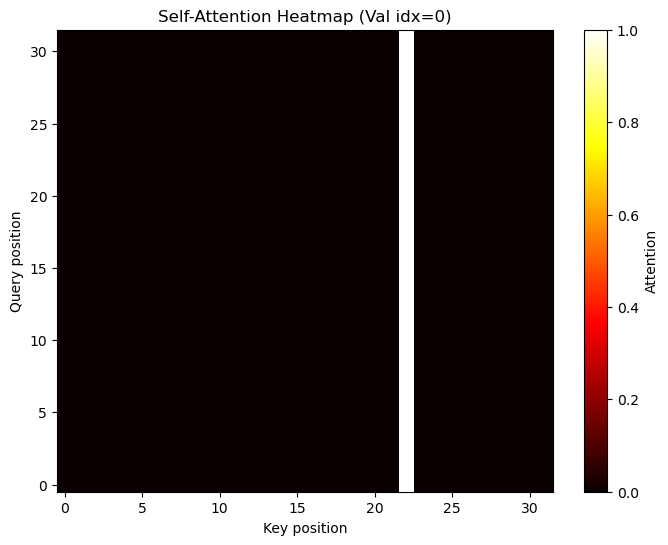

In [17]:
def plot_attention_heatmap(spec_idx):
    model.eval()
    with torch.no_grad():
        spec = torch.from_numpy(X_val_spec[spec_idx:spec_idx+1]).float().unsqueeze(1).to(device)
        feat = torch.from_numpy(X_val_feat[spec_idx:spec_idx+1]).float().to(device)
        x = model.cnn_branch(spec)
        x = model.pool(x)
        x = x.permute(0,2,1)
        attn_in = x
        attn_weights = model.attn.qkv_proj(attn_in).reshape(1, 32, 3, 4, 128).permute(2,0,3,1,4)
        q, k, v = attn_weights[0], attn_weights[1], attn_weights[2]
        score = (q @ k.transpose(-2,-1)) / np.sqrt(128)
        attn = score.softmax(dim=-1).cpu().numpy()[0,0]  # Take first head (L,L)
        plt.figure(figsize=(8,6))
        plt.imshow(attn, aspect='auto', origin='lower', cmap='hot')
        plt.colorbar(label="Attention")
        plt.xlabel("Key position"); plt.ylabel("Query position")
        plt.title(f"Self-Attention Heatmap (Val idx={spec_idx})")
        plt.show()

plot_attention_heatmap(0)

11: Visualize Single Spectrum Prediction

Val idx=1274 | True β/α: 2.57 | Pred: 2.74


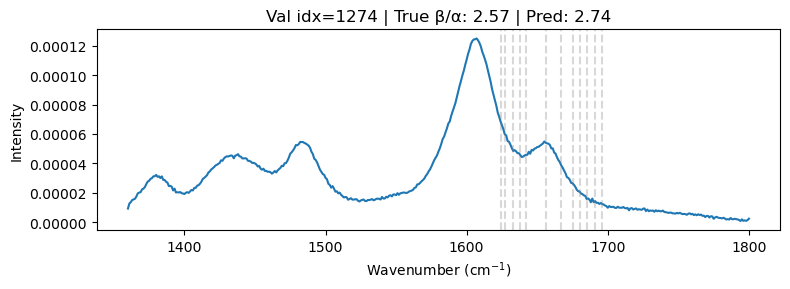

Val idx=422 | True β/α: 1.67 | Pred: 1.89


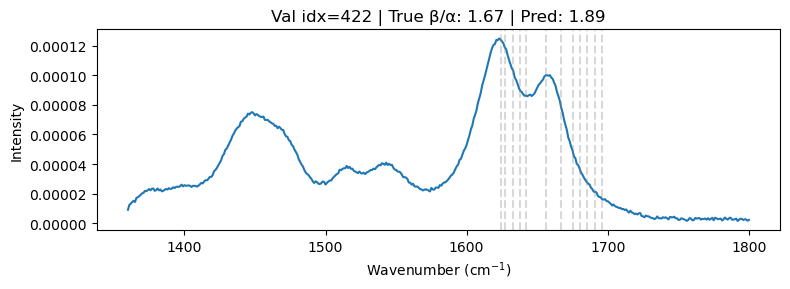

Val idx=929 | True β/α: 1.20 | Pred: 1.33


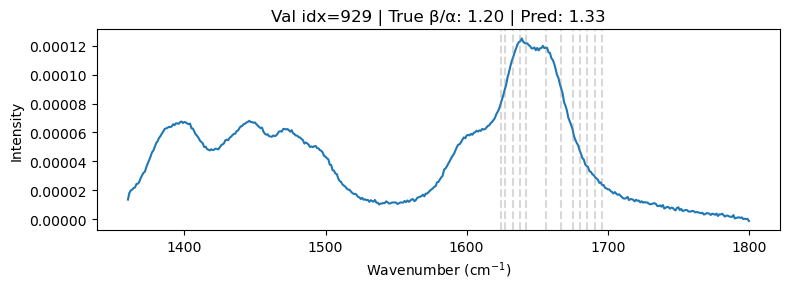

Val idx=791 | True β/α: 3.27 | Pred: 3.17


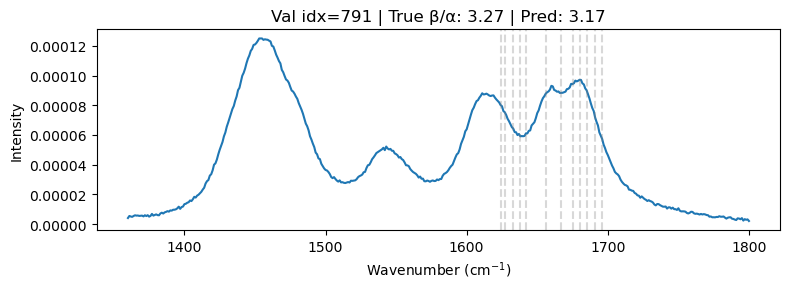

Val idx=620 | True β/α: 2.93 | Pred: 2.97


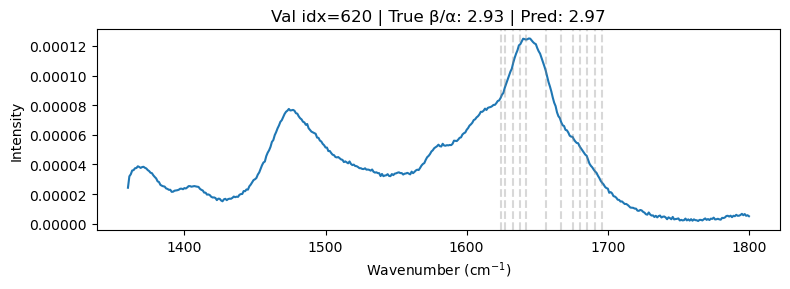

In [18]:
indices = np.random.choice(len(X_val_spec), size=5, replace=False)
for i in indices:
    print(f"Val idx={i} | True β/α: {y_val_true[i]:.2f} | Pred: {y_val_pred[i]:.2f}")
    plt.figure(figsize=(8,3))
    plt.plot(wavenumber_axis, X_val_spec[i].squeeze() * std_spec + mean_spec, label="Spectrum (unnormed)")
    for j, (_, center) in enumerate(peak_table_flat):
        plt.axvline(center, color='gray', ls='--', alpha=0.3)
    plt.xlabel("Wavenumber (cm$^{-1}$)")
    plt.ylabel("Intensity")
    plt.title(f"Val idx={i} | True β/α: {y_val_true[i]:.2f} | Pred: {y_val_pred[i]:.2f}")
    plt.tight_layout()
    plt.show()